In [3]:
import pandas as pd

In [4]:
# Define synthetic Indian retail sales data
data = {
    "OrderID": list(range(1001, 1021)),
    "Product": ["Laptop", "Smartphone", "Jeans", "LED TV", "Kurta", "Washing Machine", "Mixer Grinder", "Sports Shoes",
                "Microwave", "Earphones", "Refrigerator", "Sandals", "Tablet", "Hoodie", "Air Fryer", "Chappal",
                "Smartwatch", "Saree", "Jacket", "Toaster"],
    "Category": ["Electronics", "Electronics", "Clothing", "Electronics", "Clothing", "Appliances", "Appliances", 
                 "Footwear", "Appliances", "Electronics", "Appliances", "Footwear", "Electronics", "Clothing",
                 "Appliances", "Footwear", "Electronics", "Clothing", "Clothing", "Appliances"],
    "Quantity": [1, 2, 3, 1, 4, 1, 2, 2, 1, 3, 1, 2, 2, 1, 2, 1, 2, 3, 1, 2],
    "PricePerUnit": [60000, 20000, 1500, 45000, 800, 25000, 3000, 4000, 10000, 1500, 55000, 1200, 25000, 2000, 7000, 
                     500, 7000, 2500, 3500, 2000],
    "TotalPrice": [60000, 40000, 4500, 45000, 3200, 25000, 6000, 8000, 10000, 4500, 55000, 2400, 50000, 2000, 14000, 
                   500, 14000, 7500, 3500, 4000],
    "Date": pd.date_range(start="2024-01-01", periods=20, freq='D').strftime("%Y-%m-%d").tolist(),
    "CustomerID": ["C001", "C002", "C003", "C004", "C005", "C006", "C007", "C008", "C009", "C010", 
                   "C011", "C012", "C001", "C002", "C003", "C004", "C005", "C006", "C007", "C008"],
    "City": ["Mumbai", "Delhi", "Bengaluru", "Hyderabad", "Chennai", "Kolkata", "Pune", "Ahmedabad", "Jaipur", "Lucknow",
             "Surat", "Nagpur", "Indore", "Bhopal", "Vadodara", "Ludhiana", "Patna", "Kanpur", "Kochi", "Nashik"]
}

# Create DataFrame
df = pd.DataFrame(data)

# Save to CSV
df.to_csv("sales_data_india.csv", index=False)

print("Indian retail sales dataset saved as 'sales_data_india.csv'")

Indian retail sales dataset saved as 'sales_data_india.csv'


In [5]:
df.head()

,OrderID,Product,Category,Quantity,PricePerUnit,TotalPrice,Date,CustomerID,City
0,1001,Laptop,Electronics,1,60000,60000,2024-01-01,C001,Mumbai
1,1002,Smartphone,Electronics,2,20000,40000,2024-01-02,C002,Delhi
2,1003,Jeans,Clothing,3,1500,4500,2024-01-03,C003,Bengaluru
3,1004,LED TV,Electronics,1,45000,45000,2024-01-04,C004,Hyderabad
4,1005,Kurta,Clothing,4,800,3200,2024-01-05,C005,Chennai


In [6]:
df.isnull()

,OrderID,Product,Category,Quantity,PricePerUnit,TotalPrice,Date,CustomerID,City
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False
6,False,False,False,False,False,False,False,False,False
7,False,False,False,False,False,False,False,False,False
8,False,False,False,False,False,False,False,False,False
9,False,False,False,False,False,False,False,False,False


In [7]:
class SalesDataProcessor:
    def __init__(self, load_data):
        self.df = pd.DataFrame(data)
    
    def load_data(self, file_path):
        self.df = pd.read_csv('C:\\Users\\raiv9\\OneDrive\\python\\sales_data_india.csv')

    def clean_data(self):
        self.df.dropna(inplace=True)  # Handle missing values by dropping any row with not a number.
        self.df['TotalPrice'] = self.df['TotalPrice'].astype(float)  # Convert data types to float.
    
    def get_total_sales(self):
        return self.df['TotalPrice'].sum() # the get total sales return total sales by summing up all values in total price column.

    def get_unique_products(self):
        return self.df['Product'].unique().tolist() # the get unique product return a list of unique product by extracting unique value from
                                                     # product column
    def get_sales_by_category(self):
        return self.df.groupby('Category')['TotalPrice'].sum().reset_index() # the get_sales_by_category return total sales per product 
                                                                             # category by grouping the data frame by category and summing up total price                                            
    def get_top_selling_product(self):
        return self.df.groupby('Product')['TotalPrice'].sum().idxmax()  # The get_top_selling_product method returns the product with the highest sales by
                                                                        #grouping the DataFrame by Product and finding the product with the maximum TotalPrice.


In [8]:
processor = SalesDataProcessor(data)
processor.clean_data()
print("Total Sales:", processor.get_total_sales())
print("Unique Products:", processor.get_unique_products())
print("Sales by Category:\n", processor.get_sales_by_category())
print("Top Selling Product:", processor.get_top_selling_product())

Total Sales: 359100.0
Unique Products: ['Laptop', 'Smartphone', 'Jeans', 'LED TV', 'Kurta', 'Washing Machine', 'Mixer Grinder', 'Sports Shoes', 'Microwave', 'Earphones', 'Refrigerator', 'Sandals', 'Tablet', 'Hoodie', 'Air Fryer', 'Chappal', 'Smartwatch', 'Saree', 'Jacket', 'Toaster']
Sales by Category:
       Category  TotalPrice
0   Appliances    114000.0
1     Clothing     20700.0
2  Electronics    213500.0
3     Footwear     10900.0
Top Selling Product: Laptop


In [9]:
class CustomerSalesProcessor(SalesDataProcessor):
    def get_total_sales_by_customer(self, customer_id):
        customer_data = self.df[self.df['CustomerID'] == customer_id]
        return customer_data['TotalPrice'].sum()

    def get_frequent_customers(self, n):
        return self.df.groupby('CustomerID').size().nlargest(n)

    def get_sales_by_city(self):
        return self.df.groupby('City')['TotalPrice'].sum()


In [15]:
#Instantiate the CustomerSalesProcessor object
processor = CustomerSalesProcessor(SalesDataProcessor)
processor.load_data("sales_data_india.csv")
processor.clean_data()

# Test get_total_sales_by_customer method
customer_id = "C001"
total_sales_customer = processor.get_total_sales_by_customer(customer_id)
print(f"Total sales for customer {customer_id}: ₹{total_sales_customer:.2f}")


Total sales for customer C001: ₹110000.00


In [13]:
# Test get_frequent_customers method
top_n = 3
frequent_customers = processor.get_frequent_customers(top_n)
print(f"\nTop {top_n} customers by total purchases:")
print(frequent_customers)

# Test get_sales_by_city method
sales_by_city = processor.get_sales_by_city()
print("\nTotal sales by city:")
print(sales_by_city)


Top 3 customers by total purchases:
CustomerID
C001    2
C002    2
C003    2
dtype: int64

Total sales by city:
City
Ahmedabad     8000.0
Bengaluru     4500.0
Bhopal        2000.0
Chennai       3200.0
Delhi        40000.0
Hyderabad    45000.0
Indore       50000.0
Jaipur       10000.0
Kanpur        7500.0
Kochi         3500.0
Kolkata      25000.0
Lucknow       4500.0
Ludhiana       500.0
Mumbai       60000.0
Nagpur        2400.0
Nashik        4000.0
Patna        14000.0
Pune          6000.0
Surat        55000.0
Vadodara     14000.0
Name: TotalPrice, dtype: float64


In [16]:
import matplotlib.pyplot as plt

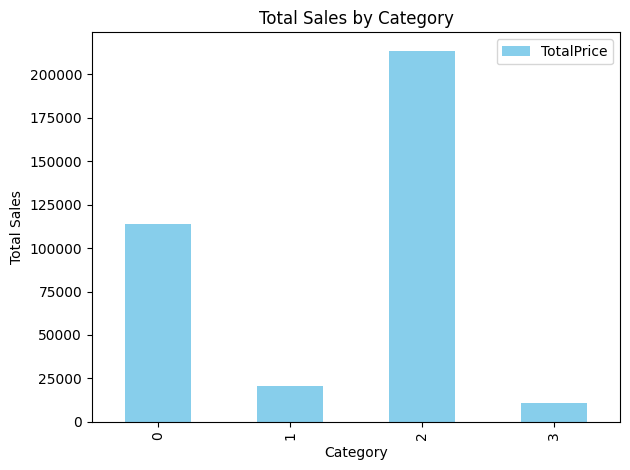

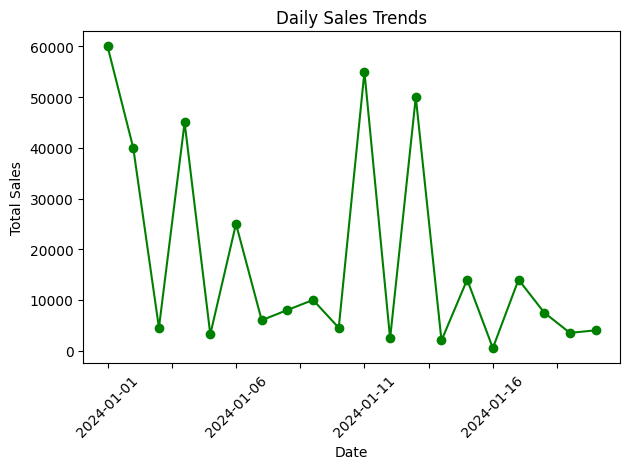

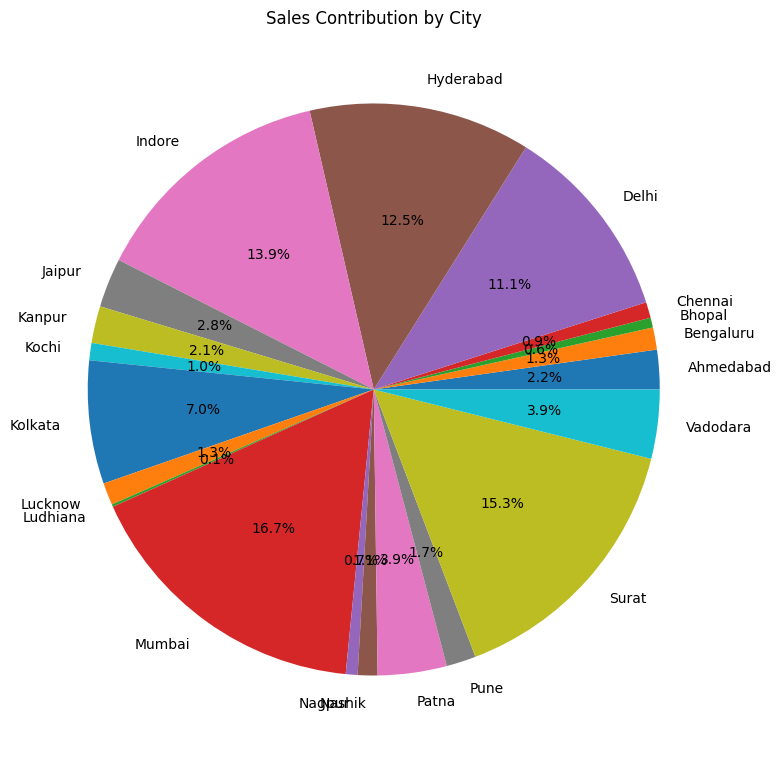

In [18]:
# Instantiate and load data
processor = CustomerSalesProcessor(SalesDataProcessor)
processor.load_data("sales_data_india.csv")
processor.clean_data()

# 1. Bar chart: Total Sales by Category
sales_by_category = processor.get_sales_by_category()
sales_by_category.plot(kind='bar', title='Total Sales by Category', ylabel='Total Sales', xlabel='Category', color='skyblue')
plt.tight_layout()
plt.show()

# 2. Line graph: Daily Sales Trends
daily_sales = processor.df.groupby('Date')['TotalPrice'].sum()
daily_sales.plot(kind='line', marker='o', title='Daily Sales Trends', ylabel='Total Sales', xlabel='Date', color='green')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3. Pie chart: Sales Contribution by City
sales_by_city = processor.get_sales_by_city()
sales_by_city.plot(kind='pie', autopct='%1.1f%%', title='Sales Contribution by City', figsize=(8,8))
plt.ylabel('')
plt.tight_layout()
plt.show()
